# Load Model Tersimpan dan Uji 1 Input Model-Ready CSV

Notebook ini sengaja dibuat strict dan sederhana: hanya menerima 2 input, yaitu file model `.joblib` dan file CSV yang sudah model-ready. `SAMPLE_ROW_INDEX` selalu merujuk ke index pada `INPUT_CSV_PATH`, bukan index dataset raw/global. Jika ingin hasil konsisten dengan notebook training, pakai `rice_training_model_ready.csv` dari output `rice_yield_model_pipeline.ipynb`.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)

In [2]:
# Dua input utama. Isi manual sesuai file yang kamu upload ke Kaggle.
# Contoh:
# MODEL_FILE_PATH = '/kaggle/input/rice-models/rice_yield_XGBoost.joblib'
# INPUT_CSV_PATH = '/kaggle/input/rice-model-ready/rice_training_model_ready.csv'
MODEL_FILE_PATH = "/kaggle/input/datasets/brspot/model-v2/rice_yield_XGBoost.joblib"
INPUT_CSV_PATH = "/kaggle/input/datasets/brspot/dataset-v3/rice_training_model_ready.csv"

SAMPLE_ROW_INDEX = 429
TARGET_COL = 'Yield'

OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def require_existing_file(path_value, variable_name):
    if path_value is None or str(path_value).strip() == '':
        raise ValueError(f'{variable_name} wajib diisi. Notebook ini tidak auto-detect agar tidak salah memilih dataset.')
    path = Path(path_value)
    if not path.exists():
        raise FileNotFoundError(f'{variable_name} tidak ditemukan: {path}')
    return path

def extract_model_features(model):
    if hasattr(model, 'feature_names_in_'):
        return list(model.feature_names_in_)

    named_steps = getattr(model, 'named_steps', {})
    for step in named_steps.values():
        if hasattr(step, 'feature_names_in_'):
            return list(step.feature_names_in_)

    preprocess = named_steps.get('preprocess') if named_steps else None
    if preprocess is not None and hasattr(preprocess, 'transformers_'):
        features = []
        for _, _, cols in preprocess.transformers_:
            if isinstance(cols, (list, tuple)):
                features.extend(cols)
        if features:
            return list(dict.fromkeys(features))

    raise ValueError('Fitur input model tidak bisa dideteksi. Pastikan model adalah sklearn Pipeline hasil training notebook Rice.')

def percent_error(actual, predicted):
    return abs(actual - predicted) / abs(actual) * 100 if actual != 0 else np.nan

In [4]:
model_path = require_existing_file(MODEL_FILE_PATH, 'MODEL_FILE_PATH')
input_csv_path = require_existing_file(INPUT_CSV_PATH, 'INPUT_CSV_PATH')

loaded_model = joblib.load(model_path)
input_df = pd.read_csv(input_csv_path)

if not 0 <= SAMPLE_ROW_INDEX < len(input_df):
    raise IndexError(f'SAMPLE_ROW_INDEX={SAMPLE_ROW_INDEX} di luar jumlah baris input: {len(input_df)}')

loaded_features = [col for col in extract_model_features(loaded_model) if col != TARGET_COL]
missing_features = [col for col in loaded_features if col not in input_df.columns]
if missing_features:
    raise ValueError(
        'INPUT_CSV_PATH belum model-ready untuk model ini. '
        f'Fitur yang hilang: {missing_features}. '
        'Gunakan rice_training_model_ready.csv dari output training atau CSV yang kolomnya sudah sama.'
    )

sample_row = input_df.iloc[[SAMPLE_ROW_INDEX]].copy()
sample_X = sample_row[loaded_features]
sample_pred_y = float(loaded_model.predict(sample_X)[0])

result = {
    'model_file': model_path.name,
    'model_path': str(model_path),
    'input_csv_path': str(input_csv_path),
    'sample_row_index': SAMPLE_ROW_INDEX,
    'predicted_yield': sample_pred_y
}

if TARGET_COL in sample_row.columns:
    sample_actual_y = float(sample_row[TARGET_COL].iloc[0])
    sample_abs_error = abs(sample_actual_y - sample_pred_y)
    sample_pct_error = percent_error(sample_actual_y, sample_pred_y)
    result.update({
        'actual_yield': sample_actual_y,
        'absolute_error': sample_abs_error,
        'percent_error': sample_pct_error
    })

print('[OK] Model berhasil di-load:', model_path)
print('[OK] Input CSV model-ready:', input_csv_path)
print('Sample row index pada input CSV:', SAMPLE_ROW_INDEX)
print('Fitur input model:', loaded_features)
print('Predicted Yield:', sample_pred_y)
if TARGET_COL in sample_row.columns:
    print('Actual Yield:', result['actual_yield'])
    print('Absolute Error:', result['absolute_error'])
    print('Percent Error:', result['percent_error'])

display(sample_row[loaded_features + ([TARGET_COL] if TARGET_COL in sample_row.columns else [])])

single_sample_result = pd.DataFrame([result])
result_path = OUTPUT_DIR / 'single_model_ready_sample_loaded_model_test.csv'
single_sample_result.to_csv(result_path, index=False)
print('[OK] Hasil uji disimpan:', result_path)
display(single_sample_result)

[OK] Model berhasil di-load: /kaggle/input/datasets/brspot/model-v2/rice_yield_XGBoost.joblib
[OK] Input CSV model-ready: /kaggle/input/datasets/brspot/dataset-v3/rice_training_model_ready.csv
Sample row index pada input CSV: 429
Fitur input model: ['Crop_Year', 'Season', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']
Predicted Yield: 3.3172452449798584
Actual Yield: 3.5
Absolute Error: 0.1827547550201416
Percent Error: 5.221564429146903


,Crop_Year,Season,Area,Annual_Rainfall,Fertilizer,Pesticide,Avg_Temperature,Max_Temperature,Min_Temperature,Yield
429,1999,Kharif,2204046.0,922.8,233915402.0,595092.42,27.279,37.275,19.094,3.5


[OK] Hasil uji disimpan: /kaggle/working/single_model_ready_sample_loaded_model_test.csv


,model_file,model_path,input_csv_path,sample_row_index,predicted_yield,actual_yield,absolute_error,percent_error
0,rice_yield_XGBoost.joblib,/kaggle/input/datasets/brspot/model-v2/rice_yi...,/kaggle/input/datasets/brspot/dataset-v3/rice_...,429,3.317245,3.5,0.182755,5.221564


In [5]:
import pandas as pd

file_path = "/kaggle/input/datasets/brspot/dataset-v3/rice_training_model_ready.csv"

df = pd.read_csv(file_path)

# Ambil baris ke-200 (ingat: index mulai dari 0)
row_200 = df.iloc[37]

print(row_200)

original_row_index                      434
Crop                                   Rice
Crop_Year                              1999
Season                          Kharif     
State                            Puducherry
Area                                25444.0
Production                            59433
Annual_Rainfall                    1434.588
Fertilizer                       2700371.72
Pesticide                           6869.88
Yield                                  2.61
Avg_Temperature                      27.736
Max_Temperature                      32.794
Min_Temperature                      23.785
yield_from_production_area         2.335836
yield_prod_area_rel_diff_pct      10.504385
removal_reason                          NaN
Name: 37, dtype: object


In [6]:
# ============================================================
# CELL 1 — Import & Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from IPython.display import display

# Load langsung dari file
FILE_PATH  = '/kaggle/input/datasets/brspot/dataset-v3/rice_training_model_ready.csv'
TARGET_COL = 'Yield'
YIELD_MIN  = 0.5
YIELD_MAX  = 6.0
BIN_SIZE   = 1.0

rice_clean_df = pd.read_csv(FILE_PATH)
rice_clean_df[TARGET_COL] = pd.to_numeric(rice_clean_df[TARGET_COL], errors='coerce')

print(f'[OK] File berhasil dibaca: {FILE_PATH}')
print(f'     Jumlah baris  : {len(rice_clean_df):,}')
print(f'     Jumlah kolom  : {len(rice_clean_df.columns)}')
print(f'     Kolom tersedia: {list(rice_clean_df.columns)}')
print(f'     Yield NaN     : {rice_clean_df[TARGET_COL].isna().sum()} baris')

[OK] File berhasil dibaca: /kaggle/input/datasets/brspot/dataset-v3/rice_training_model_ready.csv
     Jumlah baris  : 1,168
     Jumlah kolom  : 17
     Kolom tersedia: ['original_row_index', 'Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature', 'yield_from_production_area', 'yield_prod_area_rel_diff_pct', 'removal_reason']
     Yield NaN     : 0 baris


  RINGKASAN DISTRIBUSI YIELD
  Total data      : 1,168
  Yield minimum   : 0.5150
  Yield maksimum  : 4.7300
  Yield median    : 2.2075
  Yield rata-rata : 2.2139
  Std deviasi     : 0.7655
  Jumlah kluster  : 5


,Kluster,Rentang,Frekuensi,Persentase (%),Status
0,Kluster 1,0.0 – 1.0,54,4.62%,Valid
1,Kluster 2,1.0 – 2.0,414,35.45%,Valid
2,Kluster 3,2.0 – 3.0,527,45.12%,Valid
3,Kluster 4,3.0 – 4.0,157,13.44%,Valid
4,Kluster 5,4.0 – 5.0,16,1.37%,Valid


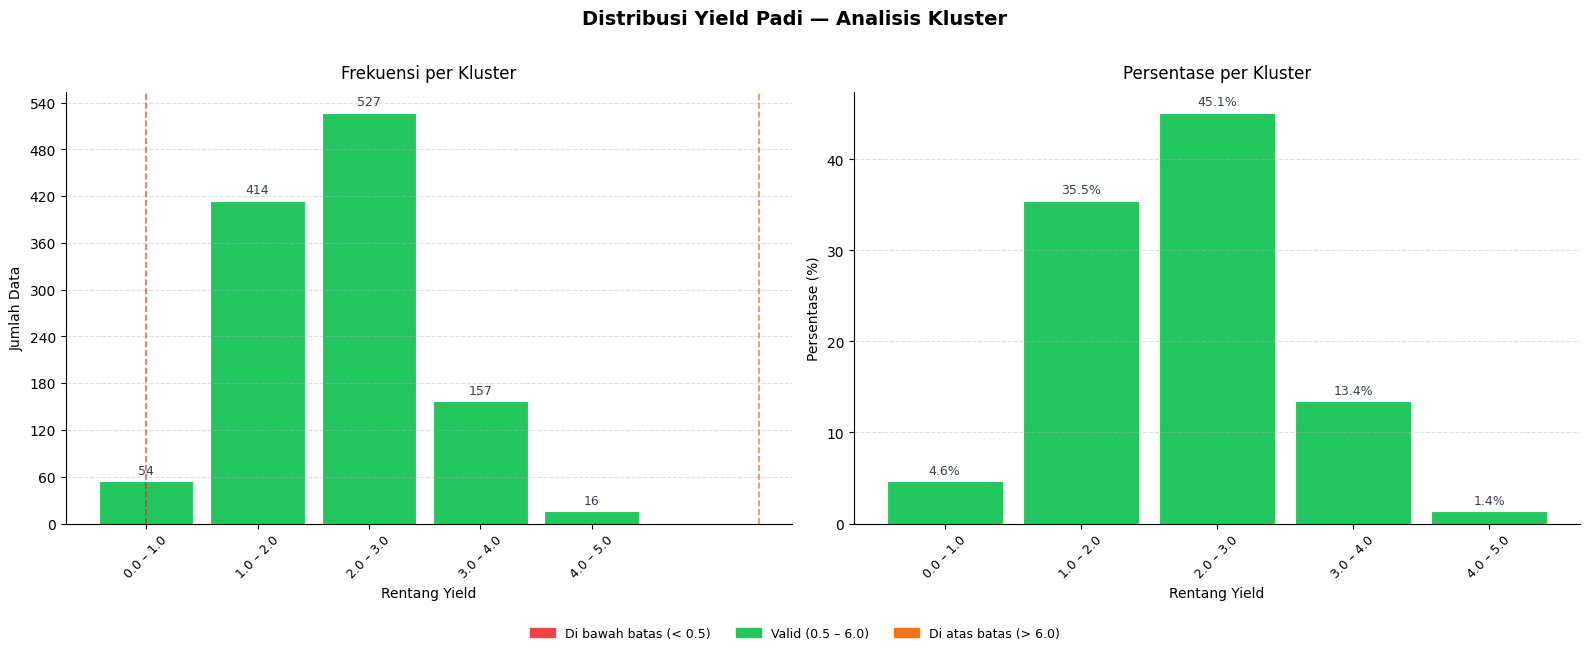

[OK] Grafik disimpan: /kaggle/working/yield_distribution.png


In [7]:
# ============================================================
# CELL 2 — Hitung Kluster & Tampilkan Tabel
# ============================================================

yield_series = rice_clean_df[TARGET_COL].dropna()

y_min_data = yield_series.min()
y_max_data = yield_series.max()

# Buat bin edges: mulai dari 0, naik BIN_SIZE, sampai ceil(max)
bin_start  = 0.0
bin_end    = np.ceil(y_max_data / BIN_SIZE) * BIN_SIZE
bin_edges  = np.arange(bin_start, bin_end + BIN_SIZE, BIN_SIZE)

# Hitung frekuensi per bin
counts, edges = np.histogram(yield_series, bins=bin_edges)

# Buat tabel ringkasan
rows = []
for i, (lo, hi, cnt) in enumerate(zip(edges[:-1], edges[1:], counts)):
    pct = cnt / len(yield_series) * 100 if len(yield_series) > 0 else 0
    
    if hi <= YIELD_MIN:
        status = 'Di bawah batas'
    elif lo >= YIELD_MAX:
        status = 'Di atas batas'
    else:
        status = 'Valid'
    
    rows.append({
        'Kluster': f'Kluster {i+1}',
        'Rentang': f'{lo:.1f} – {hi:.1f}',
        'Batas Bawah': lo,
        'Batas Atas': hi,
        'Frekuensi': cnt,
        'Persentase (%)': round(pct, 2),
        'Status': status
    })

cluster_df = pd.DataFrame(rows)

# Ringkasan statistik
print('=' * 55)
print('  RINGKASAN DISTRIBUSI YIELD')
print('=' * 55)
print(f'  Total data      : {len(yield_series):,}')
print(f'  Yield minimum   : {y_min_data:.4f}')
print(f'  Yield maksimum  : {y_max_data:.4f}')
print(f'  Yield median    : {yield_series.median():.4f}')
print(f'  Yield rata-rata : {yield_series.mean():.4f}')
print(f'  Std deviasi     : {yield_series.std():.4f}')
print(f'  Jumlah kluster  : {len(cluster_df[cluster_df["Frekuensi"] > 0])}')
print('=' * 55)

# Tampilkan tabel kluster
display(
    cluster_df[['Kluster', 'Rentang', 'Frekuensi', 'Persentase (%)', 'Status']]
    .style
    .apply(lambda row: [
        'background-color: #fdecea; color: #7f1d1d' if row['Status'] == 'Di bawah batas'
        else 'background-color: #fff7ed; color: #7c2d12' if row['Status'] == 'Di atas batas'
        else 'background-color: #f0fdf4; color: #14532d'
        for _ in row
    ], axis=1)
    .set_caption('Tabel Distribusi Yield per Kluster')
    .format({'Persentase (%)': '{:.2f}%', 'Frekuensi': '{:,}'})
)

# ============================================================
# CELL 3 — Visualisasi Histogram
# ============================================================

def color_for_bar(lo, hi, yield_min, yield_max):
    """Warna bar berdasarkan status kluster."""
    if hi <= yield_min:
        return '#ef4444'   # merah  → di bawah batas
    elif lo >= yield_max:
        return '#f97316'   # oranye → di atas batas
    else:
        return '#22c55e'   # hijau  → valid

bar_colors = [
    color_for_bar(row['Batas Bawah'], row['Batas Atas'], YIELD_MIN, YIELD_MAX)
    for _, row in cluster_df.iterrows()
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribusi Yield Padi — Analisis Kluster', fontsize=14, fontweight='bold', y=1.01)

# --- Plot kiri: Frekuensi ---
ax1 = axes[0]
bars1 = ax1.bar(
    cluster_df['Rentang'],
    cluster_df['Frekuensi'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.85
)

# Label nilai di atas bar
for bar, cnt in zip(bars1, cluster_df['Frekuensi']):
    if cnt > 0:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(cluster_df['Frekuensi']) * 0.01,
            f'{cnt:,}',
            ha='center', va='bottom', fontsize=9, color='#374151'
        )

# Garis batas YIELD_MIN dan YIELD_MAX
ax1.axvline(x=YIELD_MIN / BIN_SIZE - 0.5, color='#dc2626', linestyle='--',
            linewidth=1.2, alpha=0.7, label=f'Batas min ({YIELD_MIN})')
ax1.axvline(x=YIELD_MAX / BIN_SIZE - 0.5, color='#ea580c', linestyle='--',
            linewidth=1.2, alpha=0.7, label=f'Batas max ({YIELD_MAX})')

ax1.set_title('Frekuensi per Kluster', fontsize=12, pad=10)
ax1.set_xlabel('Rentang Yield', fontsize=10)
ax1.set_ylabel('Jumlah Data', fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

# --- Plot kanan: Persentase ---
ax2 = axes[1]
bars2 = ax2.bar(
    cluster_df['Rentang'],
    cluster_df['Persentase (%)'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.85
)

for bar, pct in zip(bars2, cluster_df['Persentase (%)']):
    if pct > 0:
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(cluster_df['Persentase (%)']) * 0.01,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=9, color='#374151'
        )

ax2.set_title('Persentase per Kluster', fontsize=12, pad=10)
ax2.set_xlabel('Rentang Yield', fontsize=10)
ax2.set_ylabel('Persentase (%)', fontsize=10)
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

# Legend warna
legend_patches = [
    mpatches.Patch(color='#ef4444', label=f'Di bawah batas (< {YIELD_MIN})'),
    mpatches.Patch(color='#22c55e', label=f'Valid ({YIELD_MIN} – {YIELD_MAX})'),
    mpatches.Patch(color='#f97316', label=f'Di atas batas (> {YIELD_MAX})'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('/kaggle/working/yield_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('[OK] Grafik disimpan: /kaggle/working/yield_distribution.png')

In [8]:
# ============================================================
# CELL — Perwakilan Tiap Kluster (nilai tengah + lokasi row)
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

FILE_PATH  = '/kaggle/input/datasets/brspot/dataset-v3/rice_training_model_ready.csv'
TARGET_COL = 'Yield'
YIELD_MIN  = 0.5
YIELD_MAX  = 6.0
BIN_SIZE   = 1.0

rice_clean_df = pd.read_csv(FILE_PATH)
rice_clean_df[TARGET_COL] = pd.to_numeric(rice_clean_df[TARGET_COL], errors='coerce')

yield_series = rice_clean_df[TARGET_COL].dropna()

# Buat bin edges
bin_end   = np.ceil(yield_series.max() / BIN_SIZE) * BIN_SIZE
bin_edges = np.arange(0.0, bin_end + BIN_SIZE, BIN_SIZE)

print('=' * 90)
print(f'  PERWAKILAN DATA PER KLUSTER  (interval = {BIN_SIZE})')
print('=' * 90)

all_rows = []

for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
    # Ambil semua baris di kluster ini (dari DataFrame asli, bukan series)
    mask    = (rice_clean_df[TARGET_COL] >= lo) & (rice_clean_df[TARGET_COL] < hi)
    members = rice_clean_df[mask].copy()

    if members.empty:
        continue

    # Tentukan status kluster
    if hi <= YIELD_MIN:
        status = 'DI BAWAH BATAS'
    elif lo >= YIELD_MAX:
        status = 'DI ATAS BATAS'
    else:
        status = 'VALID'

    # Hitung nilai tengah kluster (midpoint)
    midpoint    = (lo + hi) / 2

    # Cari baris yang nilainya paling dekat ke midpoint
    members['_dist'] = (members[TARGET_COL] - midpoint).abs()
    rep_row          = members.loc[members['_dist'].idxmin()]
    rep_original_idx = members['_dist'].idxmin()   # index di DataFrame asli
    rep_yield        = rep_row[TARGET_COL]

    # Cari juga: nilai min, median, max di kluster
    val_min    = members[TARGET_COL].min()
    val_median = members[TARGET_COL].median()
    val_max    = members[TARGET_COL].max()

    # Row index terkait min, median, max
    idx_min    = members[TARGET_COL].idxmin()
    idx_median = (members[TARGET_COL] - val_median).abs().idxmin()
    idx_max    = members[TARGET_COL].idxmax()

    all_rows.append({
        'Kluster'         : f'Kluster {i+1}',
        'Rentang'         : f'{lo:.1f} – {hi:.1f}',
        'Status'          : status,
        'Jumlah Data'     : len(members),
        'Yield Min'       : round(val_min, 4),
        'Row Min'         : idx_min,
        'Yield Median'    : round(val_median, 4),
        'Row Median'      : idx_median,
        'Yield Max'       : round(val_max, 4),
        'Row Max'         : idx_max,
        'Yield Perwakilan': round(rep_yield, 4),
        'Row Perwakilan'  : rep_original_idx,
    })

    print(f'\nKluster {i+1}  |  Rentang: {lo:.1f} – {hi:.1f}  |  Status: {status}  |  n = {len(members):,}')
    print(f'  {"Peran":<12} {"Yield":>10}  {"Row Index":>10}')
    print(f'  {"-"*36}')
    print(f'  {"Min":<12} {val_min:>10.4f}  {idx_min:>10}')
    print(f'  {"Median":<12} {val_median:>10.4f}  {idx_median:>10}')
    print(f'  {"Max":<12} {val_max:>10.4f}  {idx_max:>10}')
    print(f'  {"Perwakilan":<12} {rep_yield:>10.4f}  {rep_original_idx:>10}  ← terdekat ke midpoint {midpoint:.1f}')

print('\n' + '=' * 90)

# ── Tabel ringkasan ──────────────────────────────────────────
summary_df = pd.DataFrame(all_rows)

def row_style(row):
    if row['Status'] == 'DI BAWAH BATAS':
        return ['background-color: #fdecea; color: #7f1d1d'] * len(row)
    elif row['Status'] == 'DI ATAS BATAS':
        return ['background-color: #fff7ed; color: #7c2d12'] * len(row)
    else:
        return ['background-color: #f0fdf4; color: #14532d'] * len(row)

display(
    summary_df.style
    .apply(row_style, axis=1)
    .format({
        'Yield Min'       : '{:.4f}',
        'Yield Median'    : '{:.4f}',
        'Yield Max'       : '{:.4f}',
        'Yield Perwakilan': '{:.4f}',
        'Jumlah Data'     : '{:,}',
    })
    .set_caption('Tabel Perwakilan Tiap Kluster')
    .set_properties(**{'text-align': 'center'})
)

# ── Tampilkan baris lengkap perwakilan dari DataFrame asli ───
print('\nDetail baris perwakilan tiap kluster (dari DataFrame asli):')
print('=' * 90)

rep_indices = summary_df['Row Perwakilan'].tolist()
rep_detail  = rice_clean_df.loc[rep_indices].copy()
rep_detail.insert(0, 'Kluster', summary_df['Kluster'].values)
rep_detail.insert(1, 'Rentang', summary_df['Rentang'].values)
rep_detail.insert(2, 'Status',  summary_df['Status'].values)

display(rep_detail.reset_index(drop=False).rename(columns={'index': 'Row Index Asli'}))

  PERWAKILAN DATA PER KLUSTER  (interval = 1.0)

Kluster 1  |  Rentang: 0.0 – 1.0  |  Status: VALID  |  n = 54
  Peran             Yield   Row Index
  ------------------------------------
  Min              0.5150         656
  Median           0.8525         772
  Max              0.9990         508
  Perwakilan       0.5150         656  ← terdekat ke midpoint 0.5

Kluster 2  |  Rentang: 1.0 – 2.0  |  Status: VALID  |  n = 414
  Peran             Yield   Row Index
  ------------------------------------
  Min              1.0100         802
  Median           1.5820          45
  Max              1.9970         312
  Perwakilan       1.5010          30  ← terdekat ke midpoint 1.5

Kluster 3  |  Rentang: 2.0 – 3.0  |  Status: VALID  |  n = 527
  Peran             Yield   Row Index
  ------------------------------------
  Min              2.0000        1091
  Median           2.4750         376
  Max              2.9940          20
  Perwakilan       2.5010         283  ← terdekat ke mid

,Kluster,Rentang,Status,Jumlah Data,Yield Min,Row Min,Yield Median,Row Median,Yield Max,Row Max,Yield Perwakilan,Row Perwakilan
0,Kluster 1,0.0 – 1.0,VALID,54,0.5150,656,0.8525,772,0.9990,508,0.5150,656
1,Kluster 2,1.0 – 2.0,VALID,414,1.0100,802,1.5820,45,1.9970,312,1.5010,30
2,Kluster 3,2.0 – 3.0,VALID,527,2.0000,1091,2.4750,376,2.9940,20,2.5010,283
3,Kluster 4,3.0 – 4.0,VALID,157,3.0000,172,3.2640,345,3.9970,364,3.5000,429
4,Kluster 5,4.0 – 5.0,VALID,16,4.0120,925,4.2055,241,4.7300,286,4.4920,270



Detail baris perwakilan tiap kluster (dari DataFrame asli):


,Row Index Asli,Kluster,Rentang,Status,original_row_index,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature,yield_from_production_area,yield_prod_area_rel_diff_pct,removal_reason
0,656,Kluster 1,0.0 – 1.0,VALID,11345,Rice,2009,Autumn,Jharkhand,157262.0,87970,996.1,2.450456e+07,26734.54,0.515,23.855,34.292,14.442,0.559385,8.618442,NaN
1,30,Kluster 2,1.0 – 2.0,VALID,351,Rice,1999,Winter,Assam,1793994.0,2692709,2201.8,1.903966e+08,484378.38,1.501,24.694,34.815,16.007,1.500958,0.002822,NaN
2,283,Kluster 3,2.0 – 3.0,VALID,4316,Rice,2014,Winter,Kerala,88990.0,254450,3046.4,1.343393e+07,29366.70,2.501,25.408,32.437,19.951,2.859310,14.326671,NaN
3,429,Kluster 4,3.0 – 4.0,VALID,6990,Rice,1999,Kharif,Tamil Nadu,2204046.0,7225373,922.8,2.339154e+08,595092.42,3.500,27.279,37.275,19.094,3.278231,6.336243,NaN
4,270,Kluster 5,4.0 – 5.0,VALID,4102,Rice,2013,Kharif,Tamil Nadu,1725730.0,7115195,740.9,2.493507e+08,465947.10,4.492,28.068,37.771,20.302,4.123006,8.214472,NaN
